In [12]:
# Actually done through command line:
# %pip install global_macro_data

# %pip install git+https://github.com/TimeSynth/TimeSynth.git

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path
import timesynth as ts
import pandas as pd

from src.synthetic_ts.autoregressive import AutoRegressive

In [14]:
# Seed the random number generator for reproducibility
SEED = 67
np.random.seed(SEED)
random.seed(SEED)

In [15]:
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'
FIGURE_DIR = Path('thesis/imgs/synthethic_ts_generation')
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Synthetic time-series generation

In [16]:
def generate_timeseries(signal, noise=None, num_points=200, stop_time=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    time_sampler = ts.TimeSampler(stop_time=stop_time)
    regular_time_samples = time_sampler.sample_regular_time(num_points=num_points)
    timeseries = ts.TimeSeries(signal_generator=signal, noise_generator=noise)
    samples, signals, errors = timeseries.sample(regular_time_samples)
    return samples, regular_time_samples, signals, errors


## Export datasets

In [17]:
DATA_OUT_DIR = "thesis/data"
os.makedirs(DATA_OUT_DIR, exist_ok=True)


def make_series_df(series_id, time, values):
    return pd.DataFrame({"series_id": series_id, "time": time, "value": values})


print("Synthetic data helpers initialized; global panels are generated below.")

Synthetic data helpers initialized; global panels are generated below.


### Long AR(1) and sinusoidal for conformal diagnostics

These separate conformal diagnostics request 6,000 observations from two unchanged data-generating processes. The corrected `AutoRegressive` helper produces $y_t=0.5y_{t-1}+\epsilon_t$ with $\epsilon_t\sim\mathcal{N}(0,1)$. Following the Chapter 1 TimeSynth example, the deterministic sinusoid is sampled five times per TimeSynth time unit: $s_t=\sin(2\pi\,0.25\tau_t)$, where $\tau_t=1200t/5999$. This gives approximately 20 observed points per cycle instead of four. Their extra length supplies enough calibration and test origins for stable empirical-coverage estimates without introducing a regime or variance shift.

In [18]:
AR1_ACI_POINTS = 6000
AR1_ACI_PHI = 0.5
AR1_ACI_SIGMA = 1.0
AR1_ACI_TEST_START = 5000
SINUSOID_ACI_AMPLITUDE = 1.0
SINUSOID_ACI_FREQUENCY = 0.25
SINUSOID_ACI_STOP_TIME = AR1_ACI_POINTS / 5
CONFORMAL_OUT_DIR = "thesis/data"
os.makedirs(CONFORMAL_OUT_DIR, exist_ok=True)

ar1_signal = AutoRegressive(
    ar_param=[AR1_ACI_PHI], sigma=AR1_ACI_SIGMA
)
ar1_values, ar1_time, _, _ = generate_timeseries(
    signal=ar1_signal,
    num_points=AR1_ACI_POINTS,
    stop_time=AR1_ACI_POINTS - 1,
    seed=SEED,
)
ar1_time = np.rint(ar1_time).astype(int)
if not np.array_equal(ar1_time, np.arange(AR1_ACI_POINTS)):
    raise ValueError('The conformal AR(1) time index must be 0,...,5999')

ar1_aci_df = pd.DataFrame({
    "series_id": "ar1_conformal",
    "time": ar1_time,
    "value": ar1_values,
    "phi": AR1_ACI_PHI,
    "innovation_sigma": AR1_ACI_SIGMA,
})
ar1_aci_path = os.path.join(CONFORMAL_OUT_DIR, "synthetic_ar1_conformal.csv")
ar1_aci_df.to_csv(ar1_aci_path, index=False)
print(f"Conformal AR(1) saved to: {ar1_aci_path}")
print(
    f"Shape: {ar1_aci_df.shape}; phi={AR1_ACI_PHI}; "
    f"innovation sigma={AR1_ACI_SIGMA}"
)


sinusoidal_signal = ts.signals.Sinusoidal(
    amplitude=SINUSOID_ACI_AMPLITUDE,
    frequency=SINUSOID_ACI_FREQUENCY,
)
sinusoidal_values, sinusoidal_time, _, sinusoidal_errors = generate_timeseries(
    signal=sinusoidal_signal,
    num_points=AR1_ACI_POINTS,
    stop_time=SINUSOID_ACI_STOP_TIME,
    seed=SEED,
)
sinusoidal_observation = np.arange(AR1_ACI_POINTS, dtype=int)
expected_sinusoid = SINUSOID_ACI_AMPLITUDE * np.sin(
    2 * np.pi * SINUSOID_ACI_FREQUENCY * sinusoidal_time
)
if not np.allclose(
    sinusoidal_time,
    np.linspace(0, SINUSOID_ACI_STOP_TIME, AR1_ACI_POINTS),
):
    raise ValueError('Unexpected TimeSynth sampling grid for the conformal sinusoid')
if not np.allclose(sinusoidal_values, expected_sinusoid):
    raise ValueError('The TimeSynth sinusoid does not match the documented equation')
if not np.allclose(sinusoidal_errors, 0.0):
    raise ValueError('The conformal sinusoid must remain deterministic')

sinusoidal_aci_df = pd.DataFrame({
    "series_id": "sinusoidal_conformal",
    "time": sinusoidal_observation,
    "signal_time": sinusoidal_time,
    "value": sinusoidal_values,
    "amplitude": SINUSOID_ACI_AMPLITUDE,
    "frequency": SINUSOID_ACI_FREQUENCY,
    "innovation_sigma": 0.0,
})
sinusoidal_aci_path = os.path.join(
    CONFORMAL_OUT_DIR, "synthetic_sinusoidal_conformal.csv"
)
sinusoidal_aci_df.to_csv(sinusoidal_aci_path, index=False)
print(f"Conformal sinusoid saved to: {sinusoidal_aci_path}")
print(
    f"Shape: {sinusoidal_aci_df.shape}; "
    f"amplitude={SINUSOID_ACI_AMPLITUDE}; "
    f"frequency={SINUSOID_ACI_FREQUENCY}; "
    f"TimeSynth stop={SINUSOID_ACI_STOP_TIME}; innovation=0"
)


Conformal AR(1) saved to: thesis/data\synthetic_ar1_conformal.csv
Shape: (6000, 5); phi=0.5; innovation sigma=1.0
Conformal sinusoid saved to: thesis/data\synthetic_sinusoidal_conformal.csv
Shape: (6000, 7); amplitude=1.0; frequency=0.25; TimeSynth stop=1200.0; innovation=0


### Global forecasting benchmark

In [19]:
# Global forecasting benchmark: 3 signal-process files × 100 series × 500 observations each
NUM_SERIES_GLOBAL = 100
NUM_POINTS_GLOBAL = 500
GLOBAL_FORECAST_HORIZON = 10
STOP_TIME_GLOBAL = NUM_POINTS_GLOBAL - 1

def save_global_series(series_type, frames, data_out_dir):
    df = pd.concat(frames, ignore_index=True)
    path = os.path.join(data_out_dir, f"synthetic_ts_global_{series_type}.csv")
    df.to_csv(path, index=False)
    print(f"Saved {path}  ({df['series_id'].nunique()} series × {NUM_POINTS_GLOBAL} obs)")
    return df


# --- Autoregressive AR(1) ---
ar_frames = []
for i in range(NUM_SERIES_GLOBAL):
    signal = AutoRegressive(ar_param=[0.75], sigma=1.0)
    samples, t, _, _ = generate_timeseries(
        signal=signal, num_points=NUM_POINTS_GLOBAL, stop_time=STOP_TIME_GLOBAL, seed=SEED + i
    )
    ar_frames.append(make_series_df(f"autoregressive_{i:03d}", t, samples))
global_ar_df = save_global_series("autoregressive", ar_frames, DATA_OUT_DIR)

# --- Pseudo periodic ---
pp_frames = []
for i in range(NUM_SERIES_GLOBAL):
    # TimeSynth evaluates A_t * sin(F_t * t), without a 2*pi multiplier.
    # State the stochastic defaults explicitly so the saved DGP does not depend
    # on undocumented library defaults: A_t ~ N(1, 0.1^2) and
    # F_t ~ N(0.25, 0.4^2), independently redrawn at every observation.
    signal = ts.signals.PseudoPeriodic(
        amplitude=1.0, frequency=0.25, ampSD=0.1, freqSD=0.4
    )
    samples, t, _, _ = generate_timeseries(
        signal=signal, num_points=NUM_POINTS_GLOBAL, stop_time=STOP_TIME_GLOBAL, seed=SEED + i
    )
    pp_frames.append(make_series_df(f"pseudo_periodic_{i:03d}", t, samples))
global_pp_df = save_global_series("pseudo_periodic", pp_frames, DATA_OUT_DIR)

# --- Sinusoidal with trend and Gaussian noise ---
st_frames = []
for i in range(NUM_SERIES_GLOBAL):
    signal = ts.signals.Sinusoidal(amplitude=1, frequency=0.25)
    noise_gen = ts.noise.GaussianNoise(std=0.3)
    sinusoidal_samples, t, _, _ = generate_timeseries(
        signal=signal, noise=noise_gen, num_points=NUM_POINTS_GLOBAL, stop_time=STOP_TIME_GLOBAL, seed=SEED + i
    )
    trend = t * 0.4
    st_frames.append(make_series_df(f"sinusoidal_trend_noise_{i:03d}", t, sinusoidal_samples + trend))
global_st_df = save_global_series("sinusoidal_trend_noise", st_frames, DATA_OUT_DIR)

Saved thesis/data\synthetic_ts_global_autoregressive.csv  (100 series × 500 obs)
Saved thesis/data\synthetic_ts_global_pseudo_periodic.csv  (100 series × 500 obs)
Saved thesis/data\synthetic_ts_global_sinusoidal_trend_noise.csv  (100 series × 500 obs)


## Combined overview figure

The three global panels show the final 100 observations of their first member, including the test boundary at step 490. The two 6,000-observation conformal processes show a common 100-step window centred on their test boundary at step 5,000. The shorter windows keep local dynamics legible without changing the exported datasets.

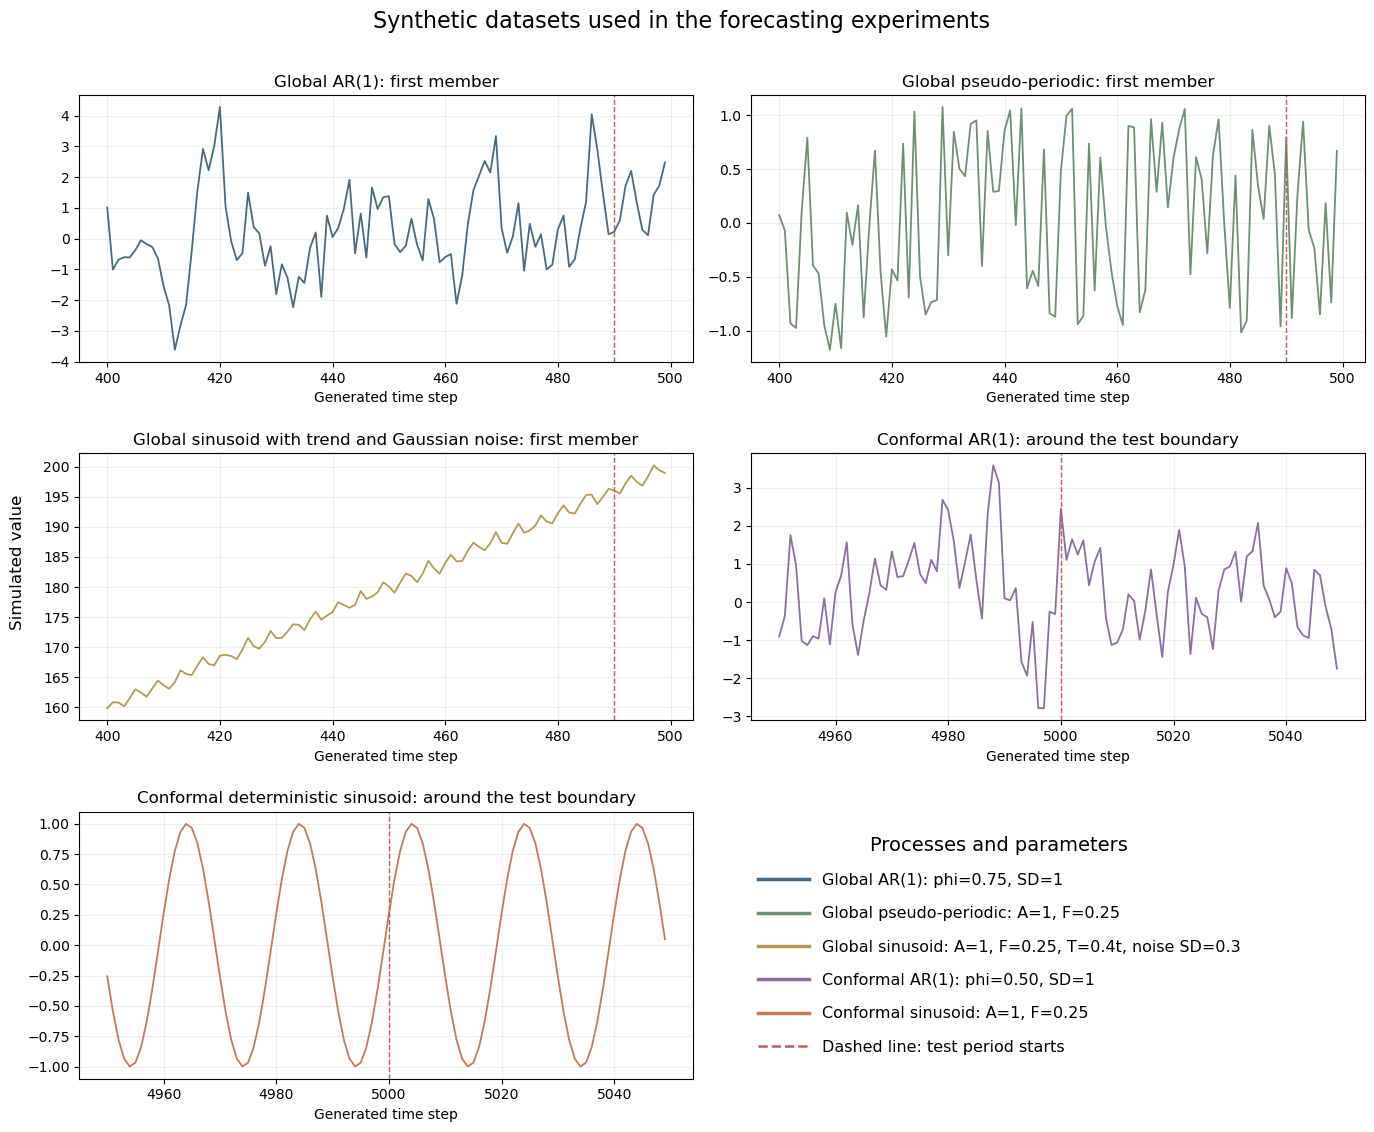

In [20]:
SYNTHETIC_PLOT_POINTS = 100
CONFORMAL_PLOT_HALF_WINDOW = SYNTHETIC_PLOT_POINTS // 2

GLOBAL_TEST_START = NUM_POINTS_GLOBAL - GLOBAL_FORECAST_HORIZON

plot_series = [
    (
        'Global AR(1): first member',
        global_ar_df.loc[global_ar_df['series_id'] == 'autoregressive_000'].tail(
            SYNTHETIC_PLOT_POINTS
        ),
        GLOBAL_TEST_START,
    ),
    (
        'Global pseudo-periodic: first member',
        global_pp_df.loc[global_pp_df['series_id'] == 'pseudo_periodic_000'].tail(
            SYNTHETIC_PLOT_POINTS
        ),
        GLOBAL_TEST_START,
    ),
    (
        'Global sinusoid with trend and Gaussian noise: first member',
        global_st_df.loc[
            global_st_df['series_id'] == 'sinusoidal_trend_noise_000'
        ].tail(SYNTHETIC_PLOT_POINTS),
        GLOBAL_TEST_START,
    ),
    (
        'Conformal AR(1): around the test boundary',
        ar1_aci_df.iloc[
            AR1_ACI_TEST_START - CONFORMAL_PLOT_HALF_WINDOW:
            AR1_ACI_TEST_START + CONFORMAL_PLOT_HALF_WINDOW
        ],
        AR1_ACI_TEST_START,
    ),
    (
        'Conformal deterministic sinusoid: around the test boundary',
        sinusoidal_aci_df.iloc[
            AR1_ACI_TEST_START - CONFORMAL_PLOT_HALF_WINDOW:
            AR1_ACI_TEST_START + CONFORMAL_PLOT_HALF_WINDOW
        ],
        AR1_ACI_TEST_START,
    ),
]

series_colors = ['#496a81', '#6f8f72', '#b49a55', '#8c6f9e', '#c47a5a']
fig, axes = plt.subplots(3, 2, figsize=(14, 11.5))
axes = axes.flatten()
for axis, (title, frame, test_start), color in zip(axes, plot_series, series_colors):
    axis.plot(frame['time'], frame['value'], color=color, linewidth=1.3)
    if frame['time'].min() < test_start <= frame['time'].max():
        axis.axvline(
            test_start, color='#b95d5d', linestyle='--',
            linewidth=1.0, label='Test starts',
        )
    axis.set(title=title, xlabel='Generated time step')
    axis.grid(alpha=0.20)

# Use the otherwise empty sixth panel for one large, readable legend.
legend_axis = axes[-1]
legend_axis.axis('off')
series_handles = [
    plt.Line2D([], [], color='#496a81', linewidth=2.5, label='Global AR(1): phi=0.75, SD=1'),
    plt.Line2D([], [], color='#6f8f72', linewidth=2.5, label='Global pseudo-periodic: mean(A)=1, mean(F)=0.25; redrawn each t'),
    plt.Line2D([], [], color='#b49a55', linewidth=2.5, label='Global sinusoid: A=1, F=0.25, T=0.4t, noise SD=0.3'),
    plt.Line2D([], [], color='#8c6f9e', linewidth=2.5, label='Conformal AR(1): phi=0.50, SD=1'),
    plt.Line2D([], [], color='#c47a5a', linewidth=2.5, label='Conformal sinusoid: A=1, F=0.25'),
    plt.Line2D([], [], color='#b95d5d', linestyle='--', linewidth=1.8, label='Dashed line: test period starts'),
]
legend_axis.legend(
    handles=series_handles,
    loc='center left',
    frameon=False,
    fontsize=11.5,
    title='Processes and parameters',
    title_fontsize=14,
    handlelength=3.2,
    labelspacing=1.15,
    borderaxespad=0.0,
)
fig.suptitle('Synthetic datasets used in the forecasting experiments', fontsize=16)
fig.supylabel('Simulated value', fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.97), h_pad=2.0)
if SAVE_FIGURES:
    fig.savefig(
        FIGURE_DIR / f'synthetic_generation_all_series.{FIGURE_FORMAT}',
        dpi=300, bbox_inches='tight',
    )
plt.show()
